In [1]:
import sys

sys.path.append("qualitative_analysis_project")
from qualitative_analysis.metrics import krippendorff, gwet

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pickle
from tqdm.notebook import tqdm

# Results for all generations

In [24]:
scl_binary = ["DIFFINST", "CWCM", "MQI_CHECK", "ORIENT", "SUMM"]
scl_three = ["APLPROB", "DIRINST", "ETCA", "EXPL", "LANGIMP", "LCP", "LINK", "LLC", "MAJERR", "MGEN", "MLANG", "MMETH", "MQI3", "OERR", "ORICH", "OWWS", "REMED", "SMQR", "STEXPL", "USEPROD", "WCDISS"]
scl_four = ["MATCON", "MMSM", "OERR4", "ORICH4", "OSPMMR4", "OWWS4", "SMALDIS", "STUCON"]
scl_five = ["LESSEFFIC", "MQI5", "TASKDEVMAT", "TSTUDEA"]

In [25]:
def get_level_domain(var):
    if var in scl_binary:
        return "nominal", [0, 1]
    if var in scl_three:
        return "ordinal", [1, 2, 3]
    if var in scl_four:
        return "ordinal", [1, 2, 3, 4]
    if var in scl_five:
        return "ordinal", [1, 2, 3, 4, 5]
    else :
        raise KeyError(f"Variable '{var}' not found in scale definitions.")

In [26]:
# To read the dict
with open("full_dictionnary_flash-lite_short-reasoning_examples.pkl", "rb") as f:
    my_dico = pickle.load(f)

## Generations

In [6]:
path_root = "VertexAI/2.5-flash-lite_short-reasoning_examples/"

for var in tqdm(my_dico):
    full_path = path_root + var + ".csv"
    df = pd.read_csv(full_path)
    rater_cols = [c for c in df.columns if c.startswith("Rater")]
    df["iteration"] = 1
    df["run"] = 1
    df["prompt_name"] = "streamlit_analysis"
    df["split"] = "train"
    my_dico[var]["df"] = df

    level, domain = get_level_domain(var)
    ac_weights = "identity" if level == "nominal" else "quadratic"

    n = len(df)
    btsp = 500 if n > 3000 else 1000 if n > 1000 else 2000 if n > 100 else 5000

    print(f"*** {var} ***")
    print(f"   Level: {level}")
    print(f"   Samples: {len(df)}")

    kripp_results = krippendorff.compute_krippendorff_non_inferiority(
    detailed_results_df = df,
    annotation_columns = rater_cols,
    model_column = "rating",
    level_of_measurement = level,
    value_domain = domain,
    non_inferiority_margin = -0.05,
    n_bootstrap = btsp,
    confidence_level = 90.0,
    random_seed = 42,
    verbose = True)

    gwet_results = gwet.compute_gwet_panel_difference(
        detailed_results_df=df,
        annotation_columns=rater_cols,
        model_column="rating",
        ac_weights=ac_weights,
        verbose=True,
    )

    my_dico[var]["kripp_results"] = kripp_results
    my_dico[var]["gwet_results"]  = gwet_results
    print()

  0%|          | 0/38 [00:00<?, ?it/s]

*** APLPROB ***
   Level: ordinal
   Samples: 4378

=== Non-inferiority Test: streamlit_analysis_iteration_1 ===
    Using 44 human annotators
    Human group: all 44 annotators
    Model groups: 44 combinations of LLM + 43 humans


Bootstrap:   0%|          | 0/500 [00:00<?, ?it/s]


  Run 1:
    Human group (44 annotators) α: 0.8001
    Model groups (LLM + 43 humans) α: 0.3640
    Δ = model − human = -0.4361
    90% CI: [-0.4523, -0.4177]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.8001 ± 0.0000
    Model substitution panel α: 0.3640 ± 0.0000
    Δ = model − human = -0.4361 ± 0.0000
    90% CI: [-0.4523, -0.4177]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 44 human annotators
    Model groups: 44 combinations of LLM + 43 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.8633
    Model substitution AC: 0.4157
    Δ = model − human = -0.4477

  Summary across 1 runs:
    Human panel AC: 0.8633 ± 0.0000
    Model substitution AC: 0.4157 ± 0.0000
    Δ = model − human = -0.4477 ± 0.0000

*** CWCM ***
   Level: nominal
   S

Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

...


  Run 1:
    Human group (25 annotators) α: 0.5687
    Model groups (LLM + 24 humans) α: 0.5341
    Δ = model − human = -0.0346
    90% CI: [-0.0921, 0.0215]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.5687 ± 0.0000
    Model substitution panel α: 0.5341 ± 0.0000
    Δ = model − human = -0.0346 ± 0.0000
    90% CI: [-0.0921, 0.0215]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 25 human annotators
    Model groups: 25 combinations of LLM + 24 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.7855
    Model substitution AC: 0.8132
    Δ = model − human = +0.0277

  Summary across 1 runs:
    Human panel AC: 0.7855 ± 0.0000
    Model substitution AC: 0.8132 ± 0.0000
    Δ = model − human = +0.0277 ± 0.0000

*** USEPROD ***
   Level: ordinal
   

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]


  Run 1:
    Human group (15 annotators) α: 0.8001
    Model groups (LLM + 14 humans) α: 0.5925
    Δ = model − human = -0.2076
    90% CI: [-0.2852, -0.1386]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.8001 ± 0.0000
    Model substitution panel α: 0.5925 ± 0.0000
    Δ = model − human = -0.2076 ± 0.0000
    90% CI: [-0.2852, -0.1386]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 15 human annotators
    Model groups: 15 combinations of LLM + 14 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.9017
    Model substitution AC: 0.8151
    Δ = model − human = -0.0866

  Summary across 1 runs:
    Human panel AC: 0.9017 ± 0.0000
    Model substitution AC: 0.8151 ± 0.0000
    Δ = model − human = -0.0866 ± 0.0000

*** WCDISS ***
   Level: ordinal
  

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]


  Run 1:
    Human group (16 annotators) α: 0.8405
    Model groups (LLM + 15 humans) α: 0.1494
    Δ = model − human = -0.6910
    90% CI: [-0.8220, -0.5628]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.8405 ± 0.0000
    Model substitution panel α: 0.1494 ± 0.0000
    Δ = model − human = -0.6910 ± 0.0000
    90% CI: [-0.8220, -0.5628]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 16 human annotators
    Model groups: 16 combinations of LLM + 15 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.9844
    Model substitution AC: 0.7730
    Δ = model − human = -0.2115

  Summary across 1 runs:
    Human panel AC: 0.9844 ± 0.0000
    Model substitution AC: 0.7730 ± 0.0000
    Δ = model − human = -0.2115 ± 0.0000



# Save and download the dictionnary

In [7]:
# To write
with open("full_dictionnary_flash-lite_short-reasoning_examples.pkl", "wb") as f:
    pickle.dump(my_dico, f, protocol=pickle.HIGHEST_PROTOCOL)

# Visualizations

In [27]:
no_codebook = ["APLPROB", "DIFFINST", "DIRINST", "MQI_CHECK", "ORIENT", "SUMM", "WCDISS"]
adapted_codebook = ["ETCA", "LLC", "SMALDIS", "USEPROD"]

reversed_var = ["LANGIMP", "LCP", "MAJERR", "OERR", "OERR4"]

scl_binary = ["DIFFINST", "CWCM", "MQI_CHECK", "ORIENT", "SUMM"]
scl_three = ["APLPROB", "DIRINST", "ETCA", "EXPL", "LANGIMP", "LCP", "LINK", "LLC", "MAJERR", "MGEN", "MLANG", "MMETH", "MQI3", "OERR", "ORICH", "OWWS", "REMED", "SMQR", "STEXPL", "USEPROD", "WCDISS"]
scl_four = ["MATCON", "MMSM", "OERR4", "ORICH4", "OSPMMR4", "OWWS4", "SMALDIS", "STUCON"]
scl_five = ["LESSEFFIC", "MQI5", "TASKDEVMAT", "TSTUDEA"]

lesson_var = ["LESSEFIC", "LLC", "MQI_CHECK", "MQI3", "MQI5", "ORIENT", "SUMM", "TASKDEVMAT", "TSTUDEA"]

In [28]:
rows_kripp = []

for var, info in my_dico.items():
    results = info["kripp_results"]
    res_key = next(iter(results)) # take first result key: "streamlit_analysis_iteration_1"
    agg = results[res_key]["aggregated_metrics"]

    rows_kripp.append({
        "Variable": var,
        "Human alpha": agg["alpha_human_panel_mean"],
        "Model alpha": agg["alpha_llm_substitution_panel_mean"],
        "Difference": agg["difference_mean"],
        "CI lower": agg["ci_lower_mean"],
        "CI upper": agg["ci_upper_mean"],
        "Non-inferior runs": agg["n_non_inferior"],
        "Total runs": agg["n_runs"],
    })

kripp_df = pd.DataFrame(rows_kripp)
kripp_df

,Variable,Human alpha,Model alpha,Difference,CI lower,CI upper,Non-inferior runs,Total runs
0,APLPROB,0.800086,0.363969,-0.436117,-0.452345,-0.417725,0,1
1,CWCM,0.800122,0.490001,-0.310121,-0.350862,-0.268365,0,1
2,DIFFINST,0.686111,0.324489,-0.361622,-0.572845,-0.136105,0,1
3,DIRINST,0.806746,0.500039,-0.306707,-0.375298,-0.240150,0,1
4,ETCA,0.846368,0.538612,-0.307756,-0.381965,-0.240932,0,1
5,EXPL,0.802558,0.458493,-0.344065,-0.418129,-0.272876,0,1
6,LANGIMP,0.812107,0.337932,-0.474175,-0.551312,-0.399675,0,1
7,LCP,0.800509,-0.002554,-0.803063,-0.885298,-0.719097,0,1
8,LESSEFFIC,0.561268,0.549772,-0.011495,-0.084420,0.056038,0,1
9,LINK,0.801190,0.462763,-0.338427,-0.376188,-0.300577,0,1


In [29]:
rows_ac = []

for var, info in my_dico.items():
    results = info["gwet_results"]
    res_key = next(iter(results)) # take first result key: "streamlit_analysis_iteration_1"
    agg = results[res_key]["aggregated_metrics"]

    rows_ac.append({
        "Variable": var,
        "Human AC": agg["ac_human_panel_mean"],
        "Model AC": agg["ac_llm_substitution_panel_mean"],
        "Delta AC": agg["difference_mean"],
    })

gwet_df = pd.DataFrame(rows_ac)
gwet_df

,Variable,Human AC,Model AC,Delta AC
0,APLPROB,0.86334,0.415672,-0.447668
1,CWCM,0.96832,0.910128,-0.058192
2,DIFFINST,0.84232,0.716678,-0.125642
3,DIRINST,0.88634,0.720972,-0.165368
4,ETCA,0.96299,0.852461,-0.110529
5,EXPL,0.94063,0.731110,-0.209520
6,LANGIMP,0.96629,0.843283,-0.123007
7,LCP,0.98290,0.509970,-0.472930
8,LESSEFFIC,0.83413,0.842755,0.008625
9,LINK,0.92029,0.711347,-0.208943


In [30]:
diff_df = pd.DataFrame(rows_kripp).sort_values("Difference")

# Add delta AC
diff_df = diff_df.merge(
    gwet_df[["Variable", "Delta AC"]],
    on="Variable",
    how="left"
)
diff_df.round(4)

,Variable,Human alpha,Model alpha,Difference,CI lower,CI upper,Non-inferior runs,Total runs,Delta AC
0,MGEN,0.8117,-0.0357,-0.8474,-0.9276,-0.7686,0,1,-0.2209
1,LCP,0.8005,-0.0026,-0.8031,-0.8853,-0.7191,0,1,-0.4729
2,MAJERR,0.8010,0.1084,-0.6925,-0.7470,-0.6404,0,1,-0.2023
3,WCDISS,0.8405,0.1494,-0.6910,-0.8220,-0.5628,0,1,-0.2115
4,MQI3,0.7328,0.1047,-0.6281,-0.8355,-0.3856,0,1,-0.1812
5,LLC,0.6782,0.0918,-0.5864,-0.8589,-0.2974,0,1,-0.1230
6,MQI_CHECK,0.6290,0.0870,-0.5420,-0.7416,-0.3351,0,1,-0.5681
7,OERR,0.8015,0.2765,-0.5250,-0.5903,-0.4585,0,1,-0.2572
8,REMED,0.8008,0.3217,-0.4792,-0.5630,-0.3973,0,1,-0.2733
9,LANGIMP,0.8121,0.3379,-0.4742,-0.5513,-0.3997,0,1,-0.1230


## Correlations

In [31]:
diff_df["Delta AC"].corr(diff_df["Difference"])

0.6248516629856786

In [32]:
diff_df["Human alpha"].corr(np.abs(diff_df["Difference"]))

0.37413209221837873

## Visualizations

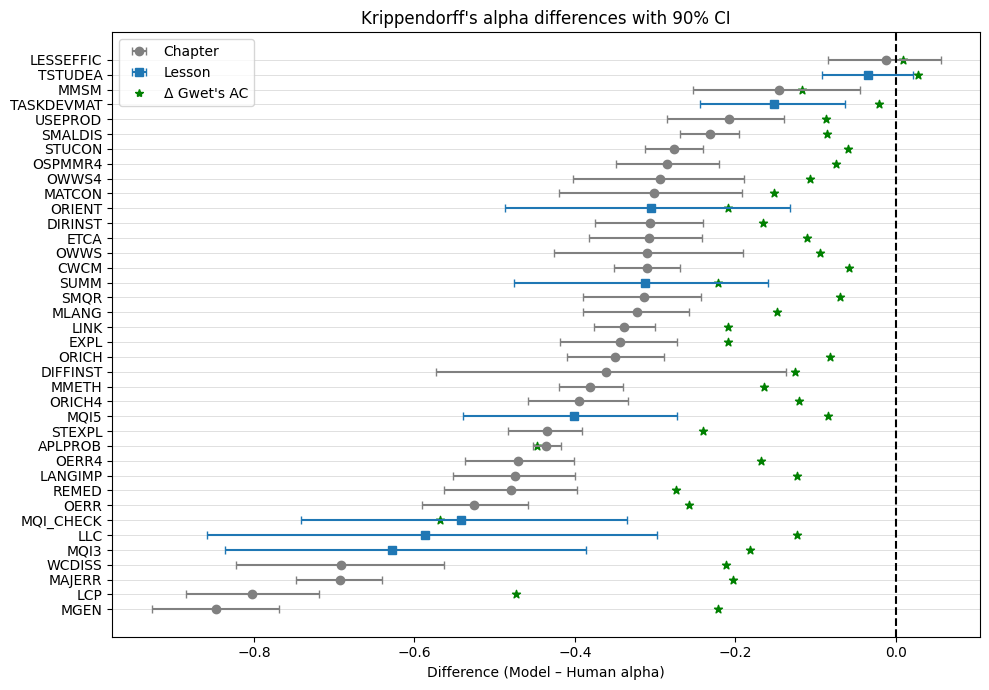

In [33]:
y = np.arange(len(diff_df))

fig, ax = plt.subplots(figsize=(10, 7))

mask = diff_df["Variable"].isin(lesson_var)

# Segment level
ax.errorbar(
    diff_df.loc[~mask, "Difference"],
    y[~mask],
    xerr=[
        diff_df.loc[~mask, "Difference"] - diff_df.loc[~mask, "CI lower"],
        diff_df.loc[~mask, "CI upper"] - diff_df.loc[~mask, "Difference"],
    ],
    fmt="o",
    color="gray",
    capsize=3,
    label="Chapter"
)

# Lesson level
ax.errorbar(
    diff_df.loc[mask, "Difference"],
    y[mask],
    xerr=[
        diff_df.loc[mask, "Difference"] - diff_df.loc[mask, "CI lower"],
        diff_df.loc[mask, "CI upper"] - diff_df.loc[mask, "Difference"],
    ],
    fmt="s", 
    capsize=3,
    label="Lesson"
)

# Gwet's AC
x_ac = diff_df["Delta AC"].astype(float).to_numpy()
y_ac = y
ax.scatter(
    x_ac,
    y_ac,
    marker="*",
    color="green",
)

for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )
ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(diff_df["Variable"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")

handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], marker='*', color='green', linestyle='None', label="Δ Gwet's AC"),
]
ax.legend(handles + custom_handles, labels + [h.get_label() for h in custom_handles])

plt.tight_layout()
# plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
summary_table_chapter = (
    diff_df.assign(Group=np.where(mask, "Lesson", "Chapter"))
    .groupby("Group")
    .agg(
        Mean_Difference=("Difference", "mean"),
        Mean_Delta_AC=("Delta AC", "mean"),
        Mean_Human_alpha=("Human alpha", "mean"),
        N=("Variable", "count")
    )
    .round(4)
)

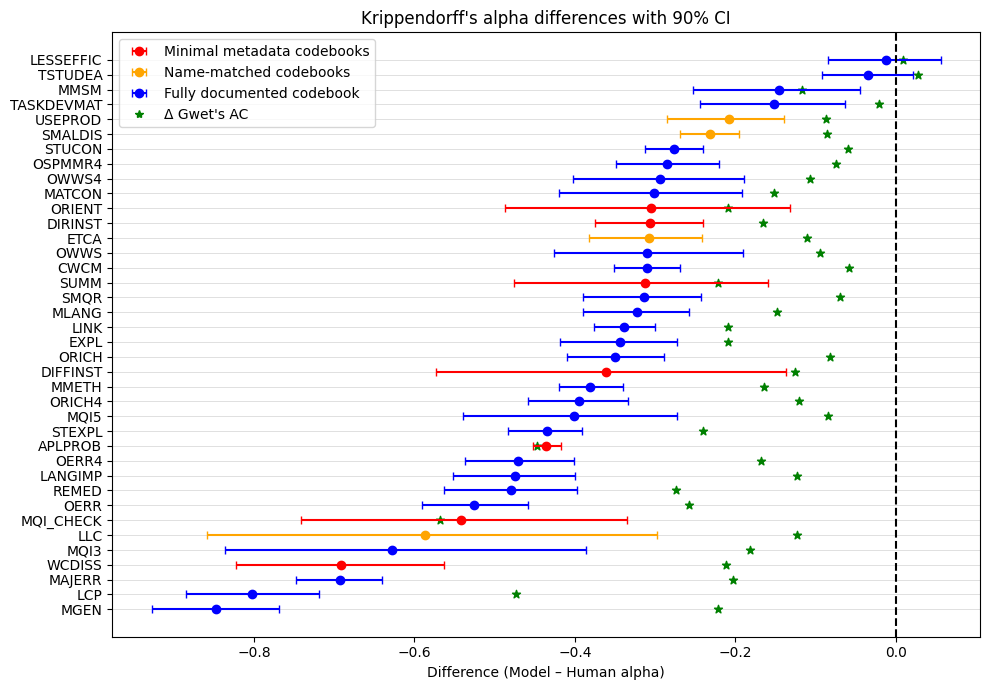

In [35]:
y = np.arange(len(diff_df))

fig, ax = plt.subplots(figsize=(10, 7))

# Masks for each scale
mask1 = diff_df["Variable"].isin(no_codebook)
mask2 = diff_df["Variable"].isin(adapted_codebook)
mask3 = ~(mask1 | mask2)

# Define a style for each list
groups = [
    (mask1, "Minimal metadata codebooks", "red"),
    (mask2, "Name-matched codebooks", "orange"),
    (mask3, "Fully documented codebook", "blue"),
]

for mask, label, color in groups:
    ax.errorbar(
        diff_df.loc[mask, "Difference"],
        y[mask],
        xerr=[
            diff_df.loc[mask, "Difference"] - diff_df.loc[mask, "CI lower"],
            diff_df.loc[mask, "CI upper"] - diff_df.loc[mask, "Difference"],
        ],
        fmt='o',
        color=color,
        capsize=3,
        label=label,
    )
# Gwet's AC
x_ac = diff_df["Delta AC"].astype(float).to_numpy()
y_ac = y
ax.scatter(
    x_ac,
    y_ac,
    marker="*",
    color="green",
)
for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )
ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(diff_df["Variable"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")

handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], marker='*', color='green', linestyle='None', label="Δ Gwet's AC"),
]
ax.legend(handles + custom_handles, labels + [h.get_label() for h in custom_handles])

plt.tight_layout()
# plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
group_col = np.select(
    [
        diff_df["Variable"].isin(no_codebook),
        diff_df["Variable"].isin(adapted_codebook)
    ],
    [
        "Minimal metadata codebooks",
        "Name-matched codebooks"
    ],
    default="Fully documented codebook"
)

order = [
    "Fully documented codebook",
    "Name-matched codebooks",
    "Minimal metadata codebooks"
]

summary_codebook = (
    diff_df.assign(Group=group_col)
    .assign(Group=lambda d: pd.Categorical(d["Group"], categories=order, ordered=True))
    .groupby("Group", observed=True)
    .agg(
        Mean_Difference=("Difference", "mean"),
        Mean_Delta_AC=("Delta AC", "mean"),
        Mean_Human_alpha=("Human alpha", "mean"),
        N=("Variable", "count")
    )
    .round(4)
)

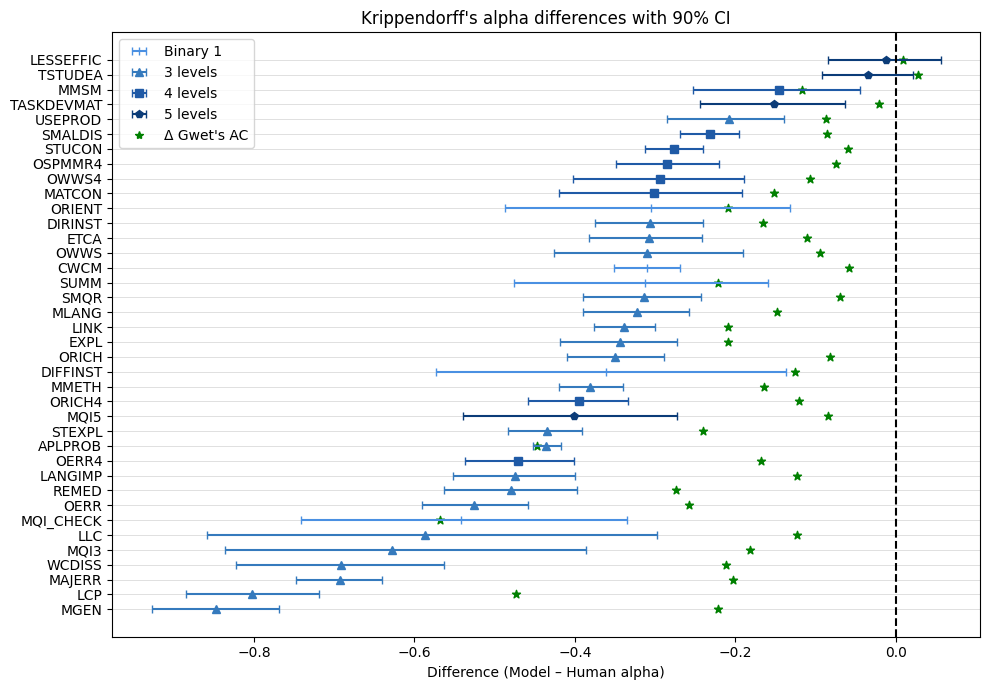

In [37]:
y = np.arange(len(diff_df))

fig, ax = plt.subplots(figsize=(10, 7))

# Masks for each scale
mask1 = diff_df["Variable"].isin(scl_binary)
mask2 = diff_df["Variable"].isin(scl_three)
mask3 = diff_df["Variable"].isin(scl_four)
mask4 = diff_df["Variable"].isin(scl_five)

# A style for each list
groups = [
    (mask1, "Binary 1", "#4a90e2", '|'),
    (mask2, "3 levels", "#357abd", "^"),
    (mask3, "4 levels", "#1f5aa6", "s"),
    (mask4, "5 levels", "#0b3c78", "p"),
]

for mask, label, color, marker in groups:
    ax.errorbar(
        diff_df.loc[mask, "Difference"],
        y[mask],
        xerr=[
            diff_df.loc[mask, "Difference"] - diff_df.loc[mask, "CI lower"],
            diff_df.loc[mask, "CI upper"] - diff_df.loc[mask, "Difference"],
        ],
        fmt=marker,
        color=color,
        capsize=3,
        label=label,
    )
# Gwet's AC
x_ac = diff_df["Delta AC"].astype(float).to_numpy()
y_ac = y
ax.scatter(
    x_ac,
    y_ac,
    marker="*",
    color="green",
)
for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )
ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(diff_df["Variable"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")

handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], marker='*', color='green', linestyle='None', label="Δ Gwet's AC"),
]
ax.legend(handles + custom_handles, labels + [h.get_label() for h in custom_handles])

plt.tight_layout()
# plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()


In [38]:
scale_group = np.select(
    [
        diff_df["Variable"].isin(scl_binary),
        diff_df["Variable"].isin(scl_three),
        diff_df["Variable"].isin(scl_four),
        diff_df["Variable"].isin(scl_five),
    ],
    [
        "Binary",
        "3 levels",
        "4 levels",
        "5 levels",
    ],
)

order = ["Binary", "3 levels", "4 levels", "5 levels"]

summary_levels = (
    diff_df.assign(Scale=scale_group)
    .assign(Scale=lambda d: pd.Categorical(d["Scale"], categories=order))
    .groupby("Scale", observed=True)
    .agg(
        Mean_Difference=("Difference", "mean"),
        Mean_Delta_AC=("Delta AC", "mean"),
        Mean_Human_alpha=("Human alpha", "mean"),
        N=("Variable", "count"),
    )
    .round(4)
)

In [39]:
big_summary = pd.concat([summary_table_chapter, summary_codebook, summary_levels], axis=0).reset_index(names="Grouping")
big_summary

,Grouping,Mean_Difference,Mean_Delta_AC,Mean_Human_alpha,N
0,Chapter,-0.3882,-0.1615,0.7928,30
1,Lesson,-0.3702,-0.1725,0.6675,8
2,Fully documented codebook,-0.3822,-0.1433,0.7709,27
3,Name-matched codebooks,-0.3333,-0.1014,0.7825,4
4,Minimal metadata codebooks,-0.4220,-0.2784,0.7400,7
5,Binary,-0.3661,-0.2365,0.7066,5
6,3 levels,-0.4656,-0.1949,0.7986,21
7,4 levels,-0.3000,-0.1101,0.7971,8
8,5 levels,-0.1499,-0.0172,0.6109,4


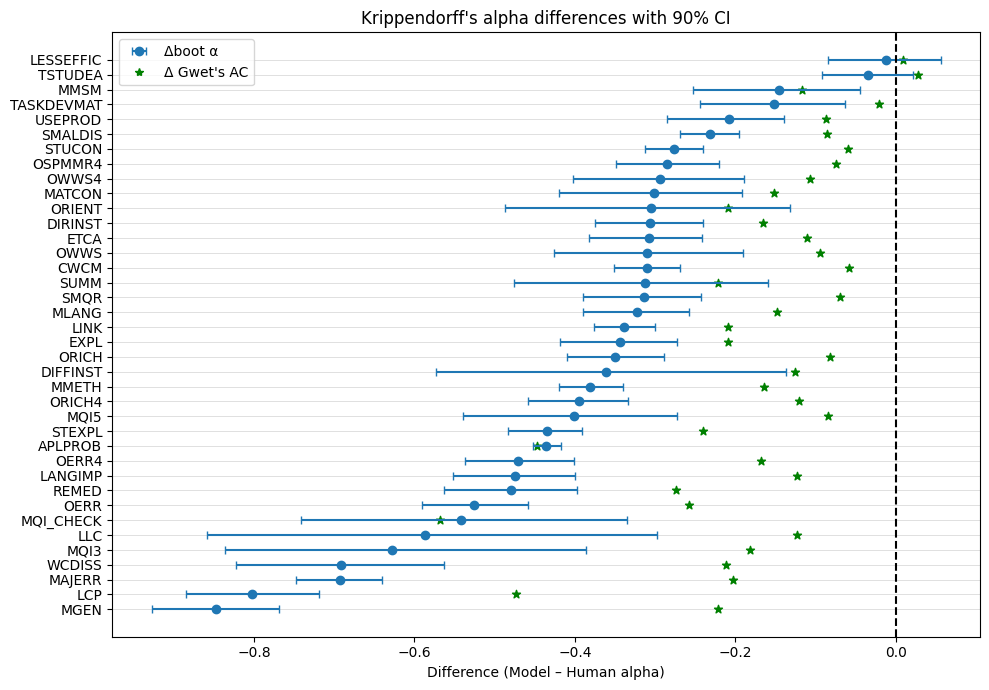

In [42]:
y = np.arange(len(diff_df))

fig, ax = plt.subplots(figsize=(10, 7))

ax.errorbar(
    diff_df["Difference"],
    y,
    xerr=[diff_df["Difference"] - diff_df["CI lower"],
          diff_df["CI upper"] - diff_df["Difference"]],
    fmt="o",
    capsize=3,
    label="Δboot α"
)

# Gwet's AC
x_ac = diff_df["Delta AC"].astype(float).to_numpy()
y_ac = y
ax.scatter(
    x_ac,
    y_ac,
    marker="*",
    color="green",
)

for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )
    
ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(diff_df["Variable"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")

handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], marker='*', color='green', linestyle='None', label="Δ Gwet's AC"),
]
ax.legend(handles + custom_handles, labels + [h.get_label() for h in custom_handles])

plt.tight_layout()
# plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()

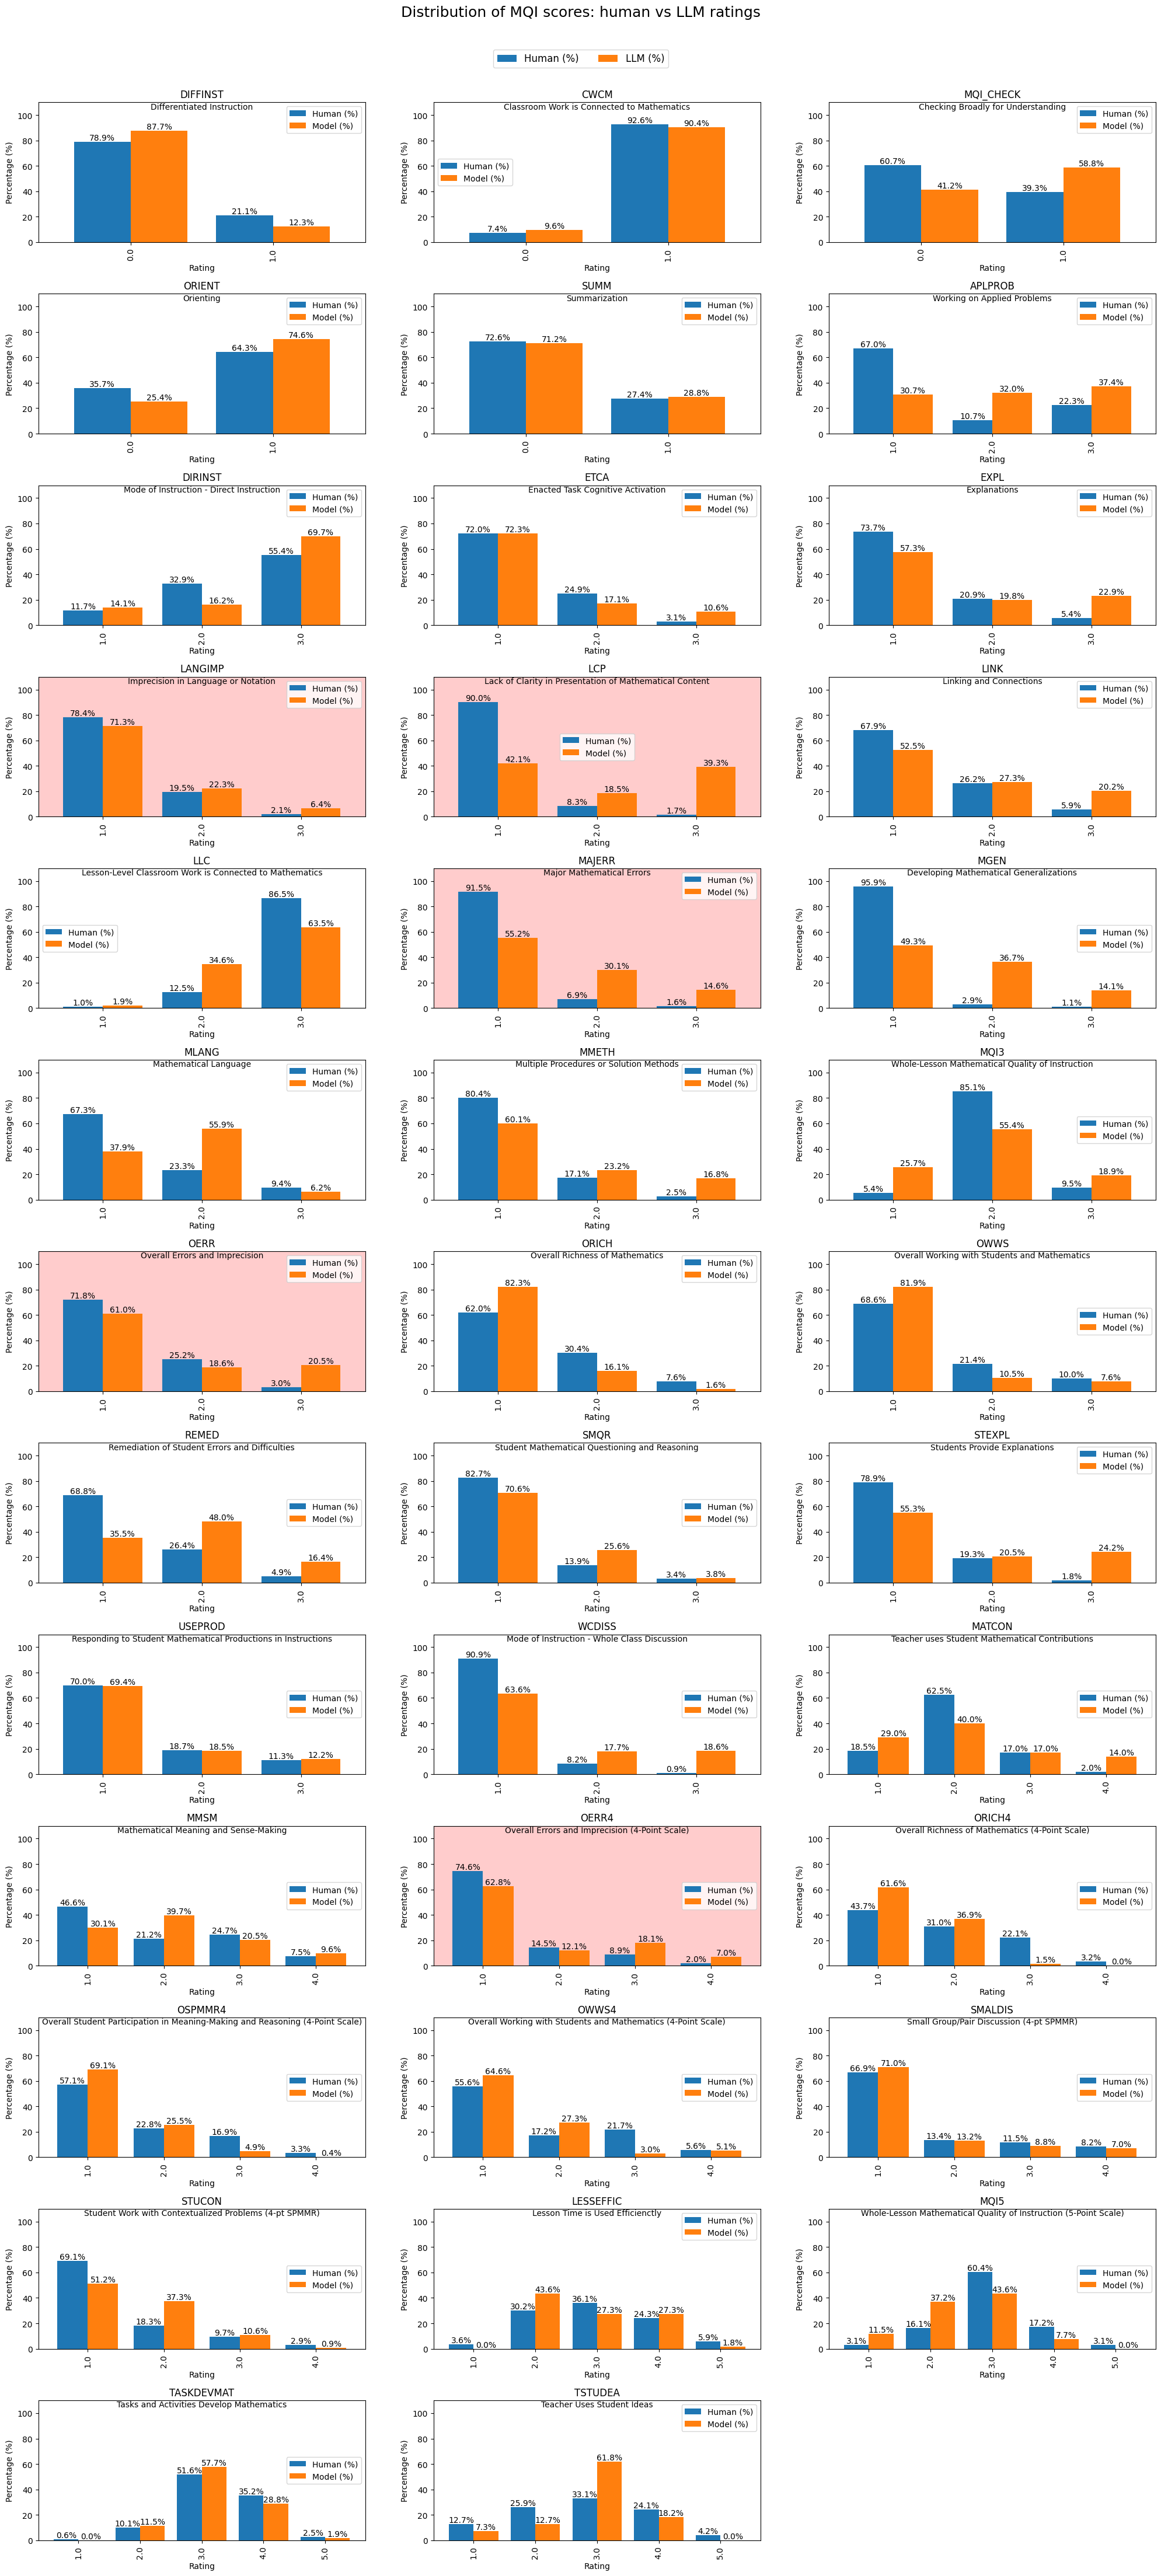

In [19]:
fig, axes = plt.subplots(ncols=3, nrows=13, figsize=(20, 45))
axes = axes.flatten()
all_vars = scl_binary + scl_three + scl_four + scl_five

for (var, ax) in zip(all_vars, axes):
    df = my_dico[var]["df"]
    rater_cols = [c for c in df.columns if c.startswith("Rater")]

    humans = df[rater_cols].stack().dropna()
    model = df["rating"]

    counts_h = humans.value_counts(normalize=True).sort_index() * 100
    counts_m = model.value_counts(normalize=True).sort_index() * 100

    idx = sorted(set(counts_h.index) | set(counts_m.index))
    plot_df = pd.DataFrame({
        "Human (%)": counts_h,
        "Model (%)": counts_m
    })

    plot_df.plot(kind="bar", ax=ax, width=0.8)
    ax.set_title(var)
    ax.text(0.5, 0.97, my_dico[var]["short_description"], ha="center", va="center", transform=ax.transAxes)
    ax.set_xlabel("Rating")
    ax.set_ylabel("Percentage (%)")
    ax.set_ylim([0, 110])
    if var in reversed_var:
        ax.set_facecolor("#ffcccc")

    # Display percent values
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=10)

fig.suptitle("Distribution of MQI scores: human vs LLM ratings", fontsize=18)
fig.legend(
    ["Human (%)", "LLM (%)"],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=2,
    fontsize=12
)

# Hide the useless axes
for ax in axes[len(all_vars):]:
    ax.set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig("kripp_diff_barplots.png", dpi=300, bbox_inches="tight")
plt.show()

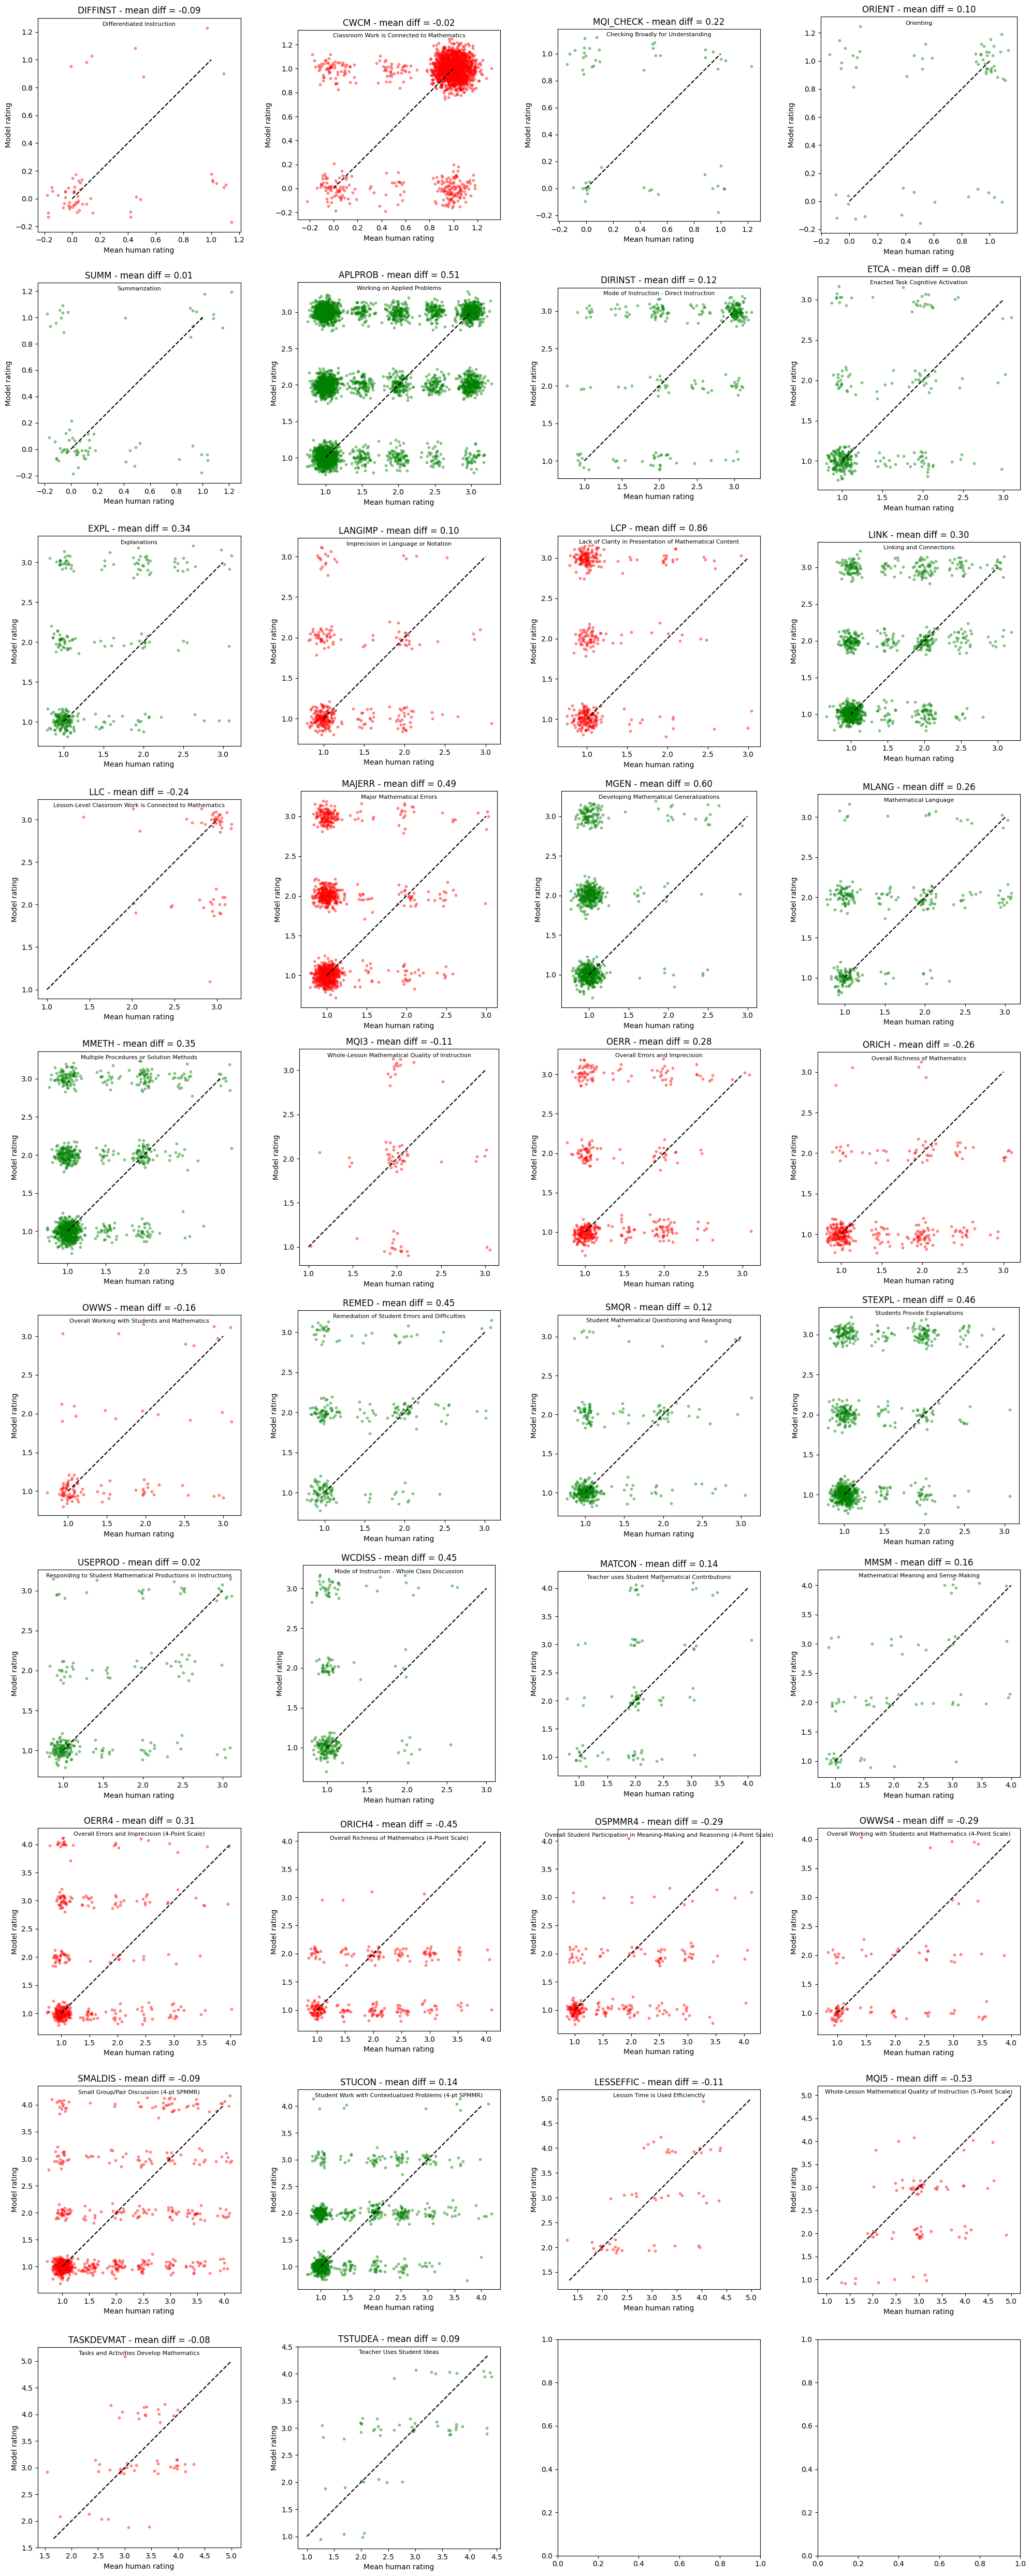

In [20]:
fig, axes = plt.subplots(ncols=4, nrows=10, figsize=(20, 50))
axes = axes.flatten()

for var, ax in zip(all_vars, axes):
    df = my_dico[var]["df"]
    rater_cols = [c for c in df.columns if c.startswith("Rater")]

    # Human mean per item
    human_mean = df[rater_cols].mean(axis=1, skipna=True)
    model = df["rating"]
    diff_mean = (model - human_mean).mean()
    if var not in reversed_var:
        colors = "green" if diff_mean > 0 else "red"
    else:
         colors = "red" if diff_mean > 0 else "green"

    # Jitter
    jitter_x = np.random.normal(0, 0.08, size=len(human_mean))
    jitter_y = np.random.normal(0, 0.08, size=len(model))

    # Scatter
    ax.scatter(
        human_mean + jitter_x,
        model + jitter_y,
        c=colors,
        alpha=0.4,
        s=10
    )

    # Diagonale y = x
    min_val = min(human_mean.min(), model.min())
    max_val = max(human_mean.max(), model.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color='black')

    ax.set_title(f"{var} - mean diff = {diff_mean:.2f}")
    ax.text(0.5, 0.97, my_dico[var]["short_description"], ha="center", va="center", transform=ax.transAxes, fontsize=8)
    ax.set_xlabel("Mean human rating")
    ax.set_ylabel("Model rating")
    ax.set_aspect("equal", "box")

plt.tight_layout()
plt.show()